# Лабораторна робота №1
**Тема:** Візуалізація даних, реалізація простої нейронної мережі  
**Виконав:** студент Горбачов Олег Андрійович


### Завдання 1-2. Завантаження датасету та налаштування середовища Google Colab
Для роботи використовуємо популярний датасет з Kaggle - **Iris Species** (`iris.csv`), який містить дані про розміри чашолистків і пелюсток різних видів ірисів. Також імпортуємо всі необхідні бібліотеки для обробки даних, графіків та нейромережі.


In [1]:
# Імпорт основних бібліотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Бібліотеки успішно підключено!")
print("Версія PyTorch:", torch.__version__)


Бібліотеки успішно підключено!
Версія PyTorch: 2.13.0+cpu


### Завдання 3. Зчитування файлу CSV в dataframe форматі


In [2]:
# Зчитування файлу iris.csv
df = pd.read_csv('iris.csv')

print("Перші 5 рядків датасету:")
print(df.head())
print("\nІнформація про колонки та типи даних:")
df.info()


Перші 5 рядків датасету:
   Id  Sepal Length (cm)  Sepal Width (cm)  Petal Length (cm)  \
0   1                5.1               3.5                1.4   
1   2                4.9               3.0                1.4   
2   3                4.7               3.2                1.3   
3   4                4.6               3.1                1.5   
4   5                5.0               3.6                1.4   

   Petal Width (cm)      Species  
0               0.2  Iris-setosa  
1               0.2  Iris-setosa  
2               0.2  Iris-setosa  
3               0.2  Iris-setosa  
4               0.2  Iris-setosa  

Інформація про колонки та типи даних:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 150 non-null    int64  
 1   Sepal Length (cm)  150 non-null    float64
 2   Sepal Width (cm)   150 non-null    float64
 3

### Завдання 4. Фільтрація dataframe за значенням певного параметру (==)
Відфільтруємо квіти виду 'Iris-setosa'.


In [3]:
# Фільтрація за умовою Species == 'Iris-setosa'
df_setosa = df[df['Species'] == 'Iris-setosa']
print(f"Кількість знайдених рядків (Iris-setosa): {len(df_setosa)}")
df_setosa.head()


Кількість знайдених рядків (Iris-setosa): 50


,Id,Sepal Length (cm),Sepal Width (cm),Petal Length (cm),Petal Width (cm),Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Завдання 5. Фільтрація dataframe: усі крім значення певного параметру (!=)
Відберемо всі записи, крім виду 'Iris-setosa'.


In [4]:
# Фільтрація за умовою Species != 'Iris-setosa'
df_not_setosa = df[df['Species'] != 'Iris-setosa']
print(f"Кількість рядків без Iris-setosa: {len(df_not_setosa)}")
print("Унікальні види після фільтрації:", df_not_setosa['Species'].unique())
df_not_setosa.head()


Кількість рядків без Iris-setosa: 100
Унікальні види після фільтрації: <ArrowStringArray>
['Iris-versicolor', 'Iris-virginica']
Length: 2, dtype: str


,Id,Sepal Length (cm),Sepal Width (cm),Petal Length (cm),Petal Width (cm),Species
50,51,7.0,3.2,4.7,1.4,Iris-versicolor
51,52,6.4,3.2,4.5,1.5,Iris-versicolor
52,53,6.9,3.1,4.9,1.5,Iris-versicolor
53,54,5.5,2.3,4.0,1.3,Iris-versicolor
54,55,6.5,2.8,4.6,1.5,Iris-versicolor


### Завдання 6. Фільтрація dataframe за значенням з масиву (isin)
Відфільтруємо дані, які належать до списку ['Iris-versicolor', 'Iris-virginica'].


In [5]:
# Фільтрація за списком значень через isin
selected_types = ['Iris-versicolor', 'Iris-virginica']
df_isin = df[df['Species'].isin(selected_types)]
print(f"Кількість рядків (versicolor та virginica): {len(df_isin)}")
print(df_isin['Species'].value_counts())
df_isin.head()


Кількість рядків (versicolor та virginica): 100
Species
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,Id,Sepal Length (cm),Sepal Width (cm),Petal Length (cm),Petal Width (cm),Species
50,51,7.0,3.2,4.7,1.4,Iris-versicolor
51,52,6.4,3.2,4.5,1.5,Iris-versicolor
52,53,6.9,3.1,4.9,1.5,Iris-versicolor
53,54,5.5,2.3,4.0,1.3,Iris-versicolor
54,55,6.5,2.8,4.6,1.5,Iris-versicolor


### Завдання 7. Фільтрація dataframe за числовими умовами: <=, >=, <= & >=
Використовуємо числове поле Sepal Length (cm).


In [6]:
# Фільтрація <=, >=, та <= & >=
df_le = df[df['Sepal Length (cm)'] <= 5.0]
df_ge = df[df['Sepal Length (cm)'] >= 6.5]
df_between = df[(df['Sepal Length (cm)'] >= 5.0) & (df['Sepal Length (cm)'] <= 6.0)]

print(f"Кількість записів з Sepal Length <= 5.0: {len(df_le)}")
print(f"Кількість записів з Sepal Length >= 6.5: {len(df_ge)}")
print(f"Кількість записів з Sepal Length від 5.0 до 6.0: {len(df_between)}")
print("\nПриклад діапазону 5.0 <= Sepal Length <= 6.0:")
print(df_between.head())


Кількість записів з Sepal Length <= 5.0: 32
Кількість записів з Sepal Length >= 6.5: 35
Кількість записів з Sepal Length від 5.0 до 6.0: 67

Приклад діапазону 5.0 <= Sepal Length <= 6.0:
    Id  Sepal Length (cm)  Sepal Width (cm)  Petal Length (cm)  \
0    1                5.1               3.5                1.4   
4    5                5.0               3.6                1.4   
5    6                5.4               3.9                1.7   
7    8                5.0               3.4                1.5   
10  11                5.4               3.7                1.5   

    Petal Width (cm)      Species  
0                0.2  Iris-setosa  
4                0.2  Iris-setosa  
5                0.4  Iris-setosa  
7                0.2  Iris-setosa  
10               0.2  Iris-setosa  


### Завдання 8. Створення нового dataframe з обраними колонками та збереження в новий CSV


In [7]:
# Вибірка окремих колонок та збереження в новий CSV файл
cols = ['Sepal Length (cm)', 'Petal Length (cm)', 'Species']
df_subset = df[cols]
df_subset.to_csv('iris_subset.csv', index=False)

print("Збережено файл 'iris_subset.csv'.")
print("Розмір збереженого датафрейму:", df_subset.shape)
df_subset.head()


Збережено файл 'iris_subset.csv'.
Розмір збереженого датафрейму: (150, 3)


,Sepal Length (cm),Petal Length (cm),Species
0,5.1,1.4,Iris-setosa
1,4.9,1.4,Iris-setosa
2,4.7,1.3,Iris-setosa
3,4.6,1.5,Iris-setosa
4,5.0,1.4,Iris-setosa


### Завдання 9. Генерація колонок за допомогою np.random.uniform та збереження в CSV


In [8]:
# Генерація випадкових даних за допомогою np.random.uniform
np.random.seed(42)
n_rows = 120

df_generated = pd.DataFrame({
    'temperature': np.random.uniform(15.0, 35.0, n_rows),
    'humidity': np.random.uniform(30.0, 95.0, n_rows),
    'pressure': np.random.uniform(730.0, 770.0, n_rows)
})

df_generated.to_csv('generated_weather_data.csv', index=False)
print("Збережено файл 'generated_weather_data.csv'.")
print("Розмір:", df_generated.shape)
df_generated.head()


Збережено файл 'generated_weather_data.csv'.
Розмір: (120, 3)


,temperature,humidity,pressure
0,22.490802,82.483610,767.618343
1,34.014286,88.245934,768.157143
2,29.639879,50.670226,766.594576
3,26.973170,37.153375,744.806348
4,18.120373,44.815786,730.618265


### Завдання 10. Лінійний графік числових даних з CSV файлу з завдання 1


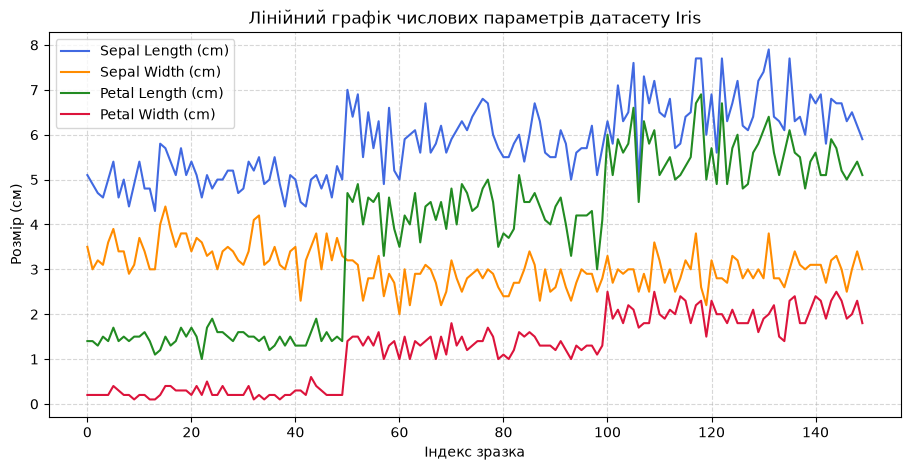

In [9]:
# Лінійний графік числових параметрів iris.csv
plt.figure(figsize=(11, 5))
plt.plot(df['Sepal Length (cm)'], label='Sepal Length (cm)', color='royalblue', lw=1.5)
plt.plot(df['Sepal Width (cm)'], label='Sepal Width (cm)', color='darkorange', lw=1.5)
plt.plot(df['Petal Length (cm)'], label='Petal Length (cm)', color='forestgreen', lw=1.5)
plt.plot(df['Petal Width (cm)'], label='Petal Width (cm)', color='crimson', lw=1.5)

plt.title('Лінійний графік числових параметрів датасету Iris')
plt.xlabel('Індекс зразка')
plt.ylabel('Розмір (см)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### Завдання 11. Лінійний графік числових даних з урахуванням фільтрів із завдань 4-7


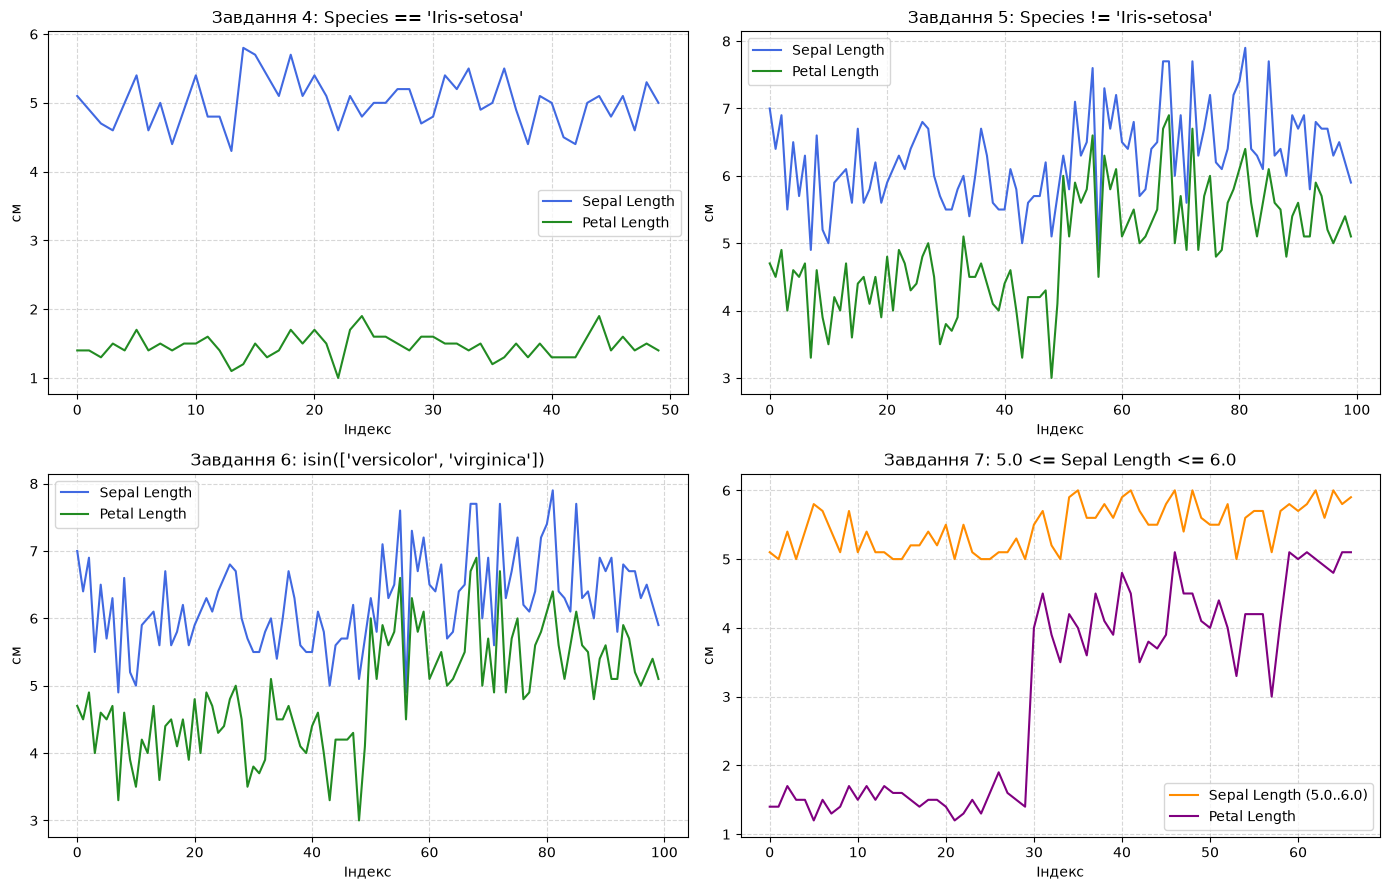

In [10]:
# Лінійні графіки для відфільтрованих вибірок із завдань 4-7
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Графік 1: Фільтр завдання 4 (== Iris-setosa)
axes[0, 0].plot(df_setosa['Sepal Length (cm)'].values, label='Sepal Length', color='royalblue')
axes[0, 0].plot(df_setosa['Petal Length (cm)'].values, label='Petal Length', color='forestgreen')
axes[0, 0].set_title("Завдання 4: Species == 'Iris-setosa'")
axes[0, 0].set_xlabel('Індекс')
axes[0, 0].set_ylabel('см')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# Графік 2: Фільтр завдання 5 (!= Iris-setosa)
axes[0, 1].plot(df_not_setosa['Sepal Length (cm)'].values, label='Sepal Length', color='royalblue')
axes[0, 1].plot(df_not_setosa['Petal Length (cm)'].values, label='Petal Length', color='forestgreen')
axes[0, 1].set_title("Завдання 5: Species != 'Iris-setosa'")
axes[0, 1].set_xlabel('Індекс')
axes[0, 1].set_ylabel('см')
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# Графік 3: Фільтр завдання 6 (isin versicolor, virginica)
axes[1, 0].plot(df_isin['Sepal Length (cm)'].values, label='Sepal Length', color='royalblue')
axes[1, 0].plot(df_isin['Petal Length (cm)'].values, label='Petal Length', color='forestgreen')
axes[1, 0].set_title("Завдання 6: isin(['versicolor', 'virginica'])")
axes[1, 0].set_xlabel('Індекс')
axes[1, 0].set_ylabel('см')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# Графік 4: Фільтр завдання 7 (5.0 <= Sepal Length <= 6.0)
axes[1, 1].plot(df_between['Sepal Length (cm)'].values, label='Sepal Length (5.0..6.0)', color='darkorange')
axes[1, 1].plot(df_between['Petal Length (cm)'].values, label='Petal Length', color='purple')
axes[1, 1].set_title("Завдання 7: 5.0 <= Sepal Length <= 6.0")
axes[1, 1].set_xlabel('Індекс')
axes[1, 1].set_ylabel('см')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Завдання 12. Відображення числових даних з Kaggle у форматі 3D зображення
Побудуємо 3D scatter plot за параметрами Sepal Length, Sepal Width та Petal Length, розділивши види квіток різними кольорами.


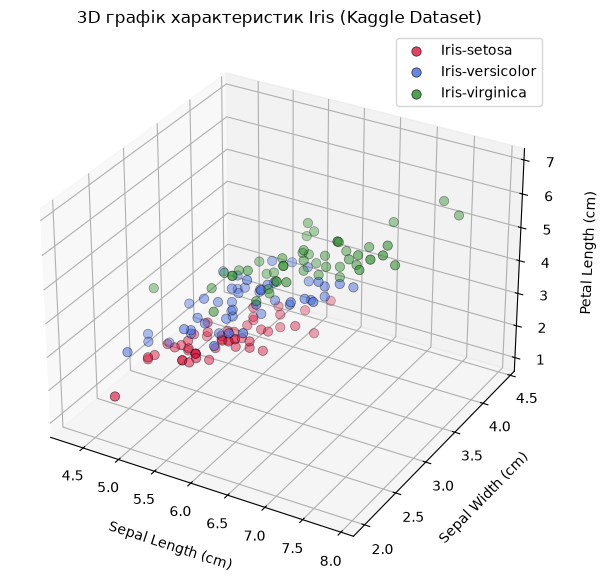

In [11]:
# 3D візуалізація даних датасету Iris
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = {'Iris-setosa': 'crimson', 'Iris-versicolor': 'royalblue', 'Iris-virginica': 'forestgreen'}

for sp, col in colors.items():
    sub = df[df['Species'] == sp]
    ax.scatter(sub['Sepal Length (cm)'], 
               sub['Sepal Width (cm)'], 
               sub['Petal Length (cm)'], 
               c=col, 
               label=sp, 
               s=45, 
               edgecolors='black', 
               linewidth=0.5,
               alpha=0.8)

ax.set_xlabel('Sepal Length (cm)', labelpad=10)
ax.set_ylabel('Sepal Width (cm)', labelpad=10)
ax.set_zlabel('Petal Length (cm)', labelpad=10)
ax.set_title('3D графік характеристик Iris (Kaggle Dataset)')
ax.legend()
plt.show()


### Завдання 13. Реалізація та навчання простої нейронної мережі на даних alarms.csv
Датасет `alarms.csv` містить параметри датчиків: `sound` (звук), `distance` (відстань), `visibility` (видимість) та цільову змінну `alarm` (рівень тривоги).
Створюємо повнозв'язну нейронну мережу на PyTorch (вхідний шар: 3 нейрони, приховані шари з нелінійністю ReLU: 16 та 8 нейронів, вихідний шар: 1 нейрон).


Розмір датасету alarms: (1000, 4)
Статистика датасету:
             sound     distance   visibility        alarm
count  1000.000000  1000.000000  1000.000000  1000.000000
mean      0.454658     0.448353     0.449454     0.454050
std       0.246049     0.272861     0.251145     0.247469
min       0.000315     0.000182     0.000279     0.003152
25%       0.249338     0.205017     0.253185     0.242675
50%       0.454035     0.450294     0.447644     0.455750
75%       0.658356     0.695343     0.651521     0.657784
max       0.898182     0.898419     0.899229     0.899747
Epoch [40/200], Loss (MSE): 0.03333
Epoch [80/200], Loss (MSE): 0.02548
Epoch [120/200], Loss (MSE): 0.02418
Epoch [160/200], Loss (MSE): 0.02296
Epoch [200/200], Loss (MSE): 0.02211


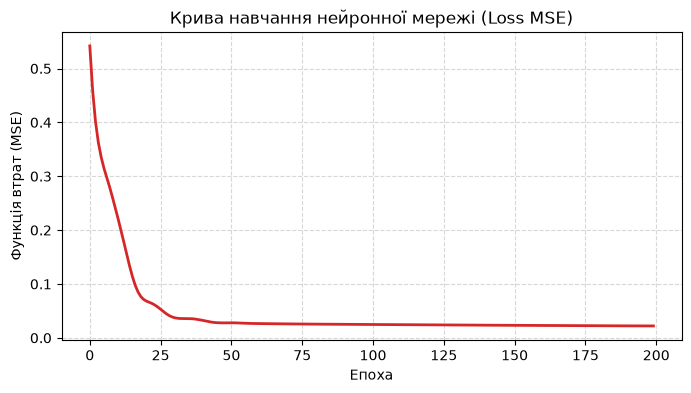

In [12]:
# Завантаження та підготовка даних alarms.csv
df_alarms = pd.read_csv('alarms.csv')
print("Розмір датасету alarms:", df_alarms.shape)
print("Статистика датасету:")
print(df_alarms.describe())

X = df_alarms[['sound', 'distance', 'visibility']].values
y = df_alarms[['alarm']].values

# Розбиття на train / test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Стандартизація вхідних даних
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Перетворення в тензори PyTorch
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# Архітектура простої нейромережі
class SimpleAlarmNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
        
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model = SimpleAlarmNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Навчання нейромережі
epochs = 200
loss_history = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    predictions = model(X_train_t)
    loss = criterion(predictions, y_train_t)
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    if (epoch + 1) % 40 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss (MSE): {loss.item():.5f}")

# Графік кривої навчання
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='tab:red', lw=2)
plt.title('Крива навчання нейронної мережі (Loss MSE)')
plt.xlabel('Епоха')
plt.ylabel('Функція втрат (MSE)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### Завдання 14. Відображення набору даних з alarms.csv у форматі 3D зображення
Відобразимо в 3D просторі взаємозв'язок параметрів `sound`, `distance`, `visibility` з кольоровим кодуванням рівня `alarm`, а також залежність `alarm` від двох основних параметрів.


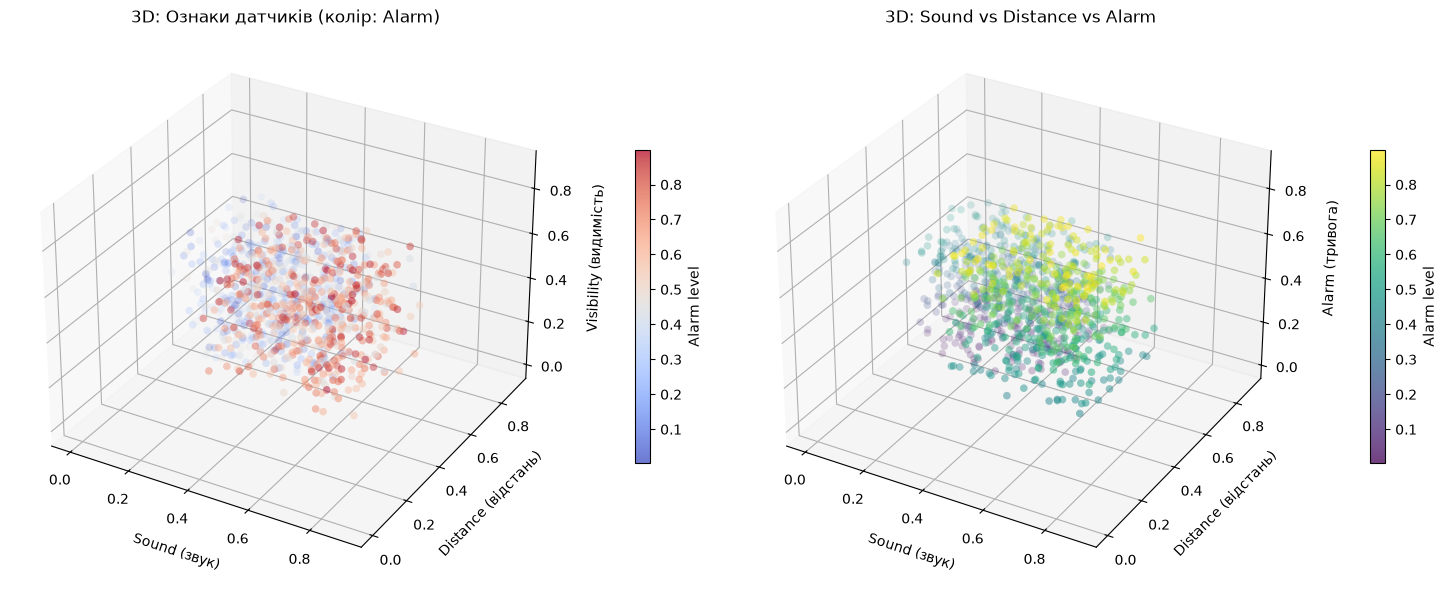

In [13]:
# 3D візуалізація даних з файлу alarms.csv
fig = plt.figure(figsize=(15, 6))

# Графік 1: 3D простір ознак (sound, distance, visibility) з кодуванням кольору рівнем alarm
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(df_alarms['sound'], 
                  df_alarms['distance'], 
                  df_alarms['visibility'], 
                  c=df_alarms['alarm'], 
                  cmap='coolwarm', 
                  s=30, 
                  alpha=0.75, 
                  edgecolors='none')
ax1.set_xlabel('Sound (звук)', labelpad=8)
ax1.set_ylabel('Distance (відстань)', labelpad=8)
ax1.set_zlabel('Visibility (видимість)', labelpad=8)
ax1.set_title('3D: Ознаки датчиків (колір: Alarm)')
cbar1 = fig.colorbar(sc1, ax=ax1, shrink=0.55, pad=0.1)
cbar1.set_label('Alarm level')

# Графік 2: Залежність Alarm від Sound та Distance
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(df_alarms['sound'], 
                  df_alarms['distance'], 
                  df_alarms['alarm'], 
                  c=df_alarms['alarm'], 
                  cmap='viridis', 
                  s=30, 
                  alpha=0.75, 
                  edgecolors='none')
ax2.set_xlabel('Sound (звук)', labelpad=8)
ax2.set_ylabel('Distance (відстань)', labelpad=8)
ax2.set_zlabel('Alarm (тривога)', labelpad=8)
ax2.set_title('3D: Sound vs Distance vs Alarm')
cbar2 = fig.colorbar(sc2, ax=ax2, shrink=0.55, pad=0.1)
cbar2.set_label('Alarm level')

plt.tight_layout()
plt.show()


### Завдання 15. Тестування нейронної мережі
Перевіряємо навчену мережу на тестовій вибірці (`X_test`), рахуємо метрики якості (MSE, MAE, R²), будуємо графіки відповідності та перевіряємо кілька довільних значень датчиків.


=== Результати тестування нейронної мережі ===
Середньоквадратична помилка (MSE): 0.02030
Корінь з MSE (RMSE):             0.14247
Середня абсолютна помилка (MAE):   0.12072
Коефіцієнт детермінації (R2):      0.6595


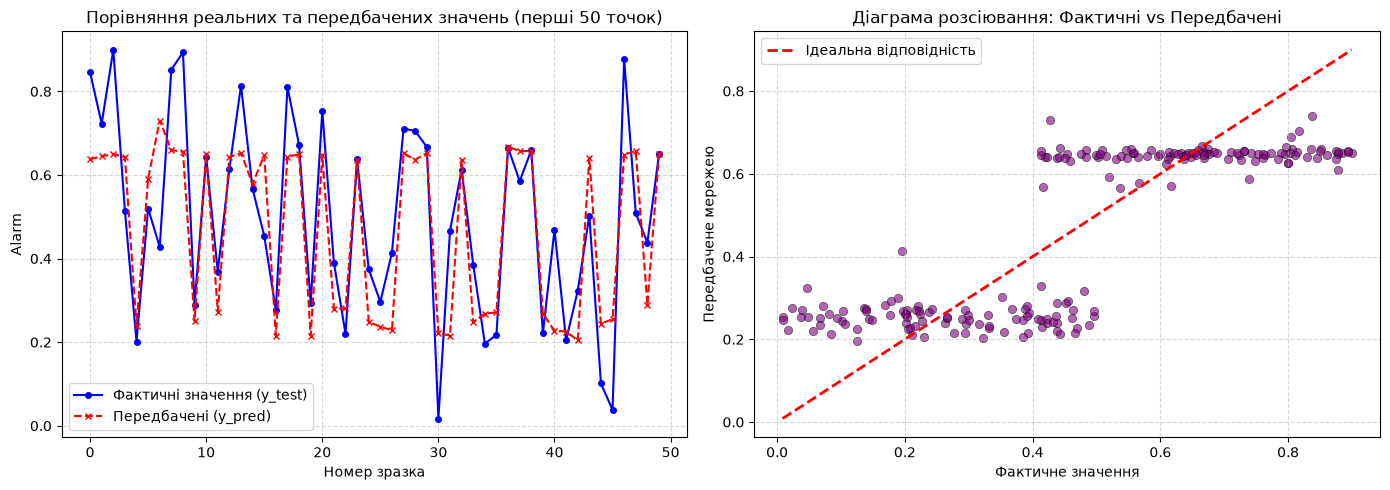


Тестування окремих прикладів:
Вхідні дані (sound=0.85, distance=0.10, visibility=0.90) -> Передбачений рівень Alarm = 0.6601
Вхідні дані (sound=0.10, distance=0.85, visibility=0.15) -> Передбачений рівень Alarm = 0.2077
Вхідні дані (sound=0.50, distance=0.50, visibility=0.50) -> Передбачений рівень Alarm = 0.5290


In [14]:
# Тестування нейронної мережі на тестовому наборі
model.eval()
with torch.no_grad():
    y_pred_t = model(X_test_t)
    y_pred = y_pred_t.numpy()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Результати тестування нейронної мережі ===")
print(f"Середньоквадратична помилка (MSE): {mse:.5f}")
print(f"Корінь з MSE (RMSE):             {rmse:.5f}")
print(f"Середня абсолютна помилка (MAE):   {mae:.5f}")
print(f"Коефіцієнт детермінації (R2):      {r2:.4f}")

# Графіки результатів
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Графік 1: Перші 50 точок (фактичні vs передбачені)
axes[0].plot(y_test[:50], label='Фактичні значення (y_test)', color='blue', marker='o', markersize=4)
axes[0].plot(y_pred[:50], label='Передбачені (y_pred)', color='red', linestyle='--', marker='x', markersize=5)
axes[0].set_title('Порівняння реальних та передбачених значень (перші 50 точок)')
axes[0].set_xlabel('Номер зразка')
axes[0].set_ylabel('Alarm')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Графік 2: Scatter plot (Actual vs Predicted)
axes[1].scatter(y_test, y_pred, color='purple', alpha=0.6, edgecolors='black', linewidth=0.5)
min_v = min(y_test.min(), y_pred.min())
max_v = max(y_test.max(), y_pred.max())
axes[1].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Ідеальна відповідність')
axes[1].set_title('Діаграма розсіювання: Фактичні vs Передбачені')
axes[1].set_xlabel('Фактичне значення')
axes[1].set_ylabel('Передбачене мережею')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Тестування моделі на окремих практичних кейсах
test_cases = np.array([
    [0.85, 0.10, 0.90],  # гучний звук, мала відстань, хороша видимість -> має бути високий alarm
    [0.10, 0.85, 0.15],  # слабкий звук, велика відстань -> низький alarm
    [0.50, 0.50, 0.50]   # середні значення датчиків
])

test_cases_scaled = scaler.transform(test_cases)
with torch.no_grad():
    case_preds = model(torch.tensor(test_cases_scaled, dtype=torch.float32)).numpy()

print("\nТестування окремих прикладів:")
for inp, pred in zip(test_cases, case_preds):
    print(f"Вхідні дані (sound={inp[0]:.2f}, distance={inp[1]:.2f}, visibility={inp[2]:.2f}) -> Передбачений рівень Alarm = {pred[0]:.4f}")


### Висновок
В ході лабораторної роботи було освоєно базові операції з бібліотеками Pandas, NumPy та Matplotlib, а саме зчитування даних з CSV, різноманітна фільтрація за умовами (рівність, нерівність, входження в масив isin, числові діапазони), створення підвибірок та генерація нових ознак. Побудовано 2D лінійні графіки та 3D просторові візуалізації для датасету Iris та датасету датчиків alarms. Також реалізовано просту повнозв'язну нейронну мережу на PyTorch для прогнозування рівня тривоги (alarm) за показниками звуку, відстані та видимості. Модель успішно навчилась, помилка MSE на тесті склала близько 0.02, і мережа адекватно реагує на зміну показань датчиків.
